# Week 5: CNNs For Text

This notebook studies `TextCNN` for sentiment classification using the same IMDb tokenization pipeline, split seed, and pretrained `DAN` embedding used in Weeks 3 and 4.

## Learning Goals
- Understand `1D` convolution as a sliding window over token embeddings.
- Show how multiple filters at widths `6`, `10`, and `16` learn different local phrase detectors over the BPE token sequence.
- Explain why parameter sharing lets one filter detect a useful pattern anywhere in the sequence.
- Compare global max pooling and mean pooling conceptually.
- Build and train a `TextCNN` model on IMDb.
- Inspect learned feature maps after training and connect them back to pooling.
- Close with a short CNN vs. RNN reflection.

## Reused Assets
This week reuses the saved artifacts from previous weeks so the modeling comparison stays consistent:

- `./data/imdb_bpe_dataset.pt`
- `./data/bpe_vocab.json`
- `./data/bpe_merges.json`
- `./models/vocab_config.json`
- `./models/dan_imdb.pt`

The dataset split follows the Week 4 setup: `80/10/10` with `manual_seed(204)`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

from utils import (
    bpe_batch_encode,
    build_conv_mask,
    clean_memory,
    evaluate_model,
    get_approx_word_window_spans,
    get_device,
    load_json,
    load_pretrained_embedding,
    load_torch_dataset,
    plot_feature_map_heatmap,
    train_test_model,
    word_tokenizer,
)

In [2]:
paths = {
    "dataset": Path("./data/imdb_bpe_dataset.pt"),
    "bpe_vocab": Path("./data/bpe_vocab.json"),
    "bpe_merges": Path("./data/bpe_merges.json"),
    "vocab_config": Path("./models/vocab_config.json"),
    "dan_state": Path("./models/dan_imdb.pt"),
}

missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required Week 5 assets:\n" + "\n".join(missing))

input_ids, labels, attention_masks = load_torch_dataset(str(paths["dataset"]))
bpe_vocab = load_json(str(paths["bpe_vocab"]))
bpe_merges = load_json(str(paths["bpe_merges"]))
vocab_config = load_json(str(paths["vocab_config"]))

pad_id = vocab_config["pad_id"]
vocab_size = vocab_config["vocab_size"]
max_seq = vocab_config["max_seq"]
pad_token = vocab_config["pad_token"]
device = get_device()

print(f"input_ids shape: {tuple(input_ids.shape)}")
print(f"labels shape: {tuple(labels.shape)}")
print(f"attention mask shape: {tuple(attention_masks.shape)}")
print(f"device: {device}")

input_ids shape: (50000, 128)
labels shape: (50000,)
attention mask shape: (50000, 128)
device: mps


## 1D CNN Intuition
A `TextCNN` treats text as a sequence of token embeddings. In this notebook, the sequence is a byte-level BPE token sequence rather than a plain word sequence, so each convolution runs over local BPE-token windows.

Each filter is its own learned pattern detector. If we use `64` filters for width `6`, that means the model learns `64` different short-context detectors rather than one generic n-gram feature. The same idea applies to the wider `10`- and `16`-token filters.

The same filter is reused across the full sequence. That is parameter sharing. A useful way to think about it is how we read: our brain naturally notices short word patterns like `not good`, `very funny`, or `too slow` no matter where they appear on a page. A CNN filter works in a similar way. It learns one local pattern detector and then applies that same detector everywhere in the review.

## Pooling Intuition
After a convolution is applied, each filter produces a feature map over the entire sentence. In the actual model, the filter scores every valid sliding window over the BPE token sequence.

Suppose one filter has learned to respond strongly to a positive local pattern. For a sequence of length `n`, a filter of width `k` produces `n-k+1` scores: one score for each valid sliding-window position.

Global pooling is then applied **across all positions for that one filter**:

- `max pooling` keeps the single largest score in that feature map.
- `mean pooling` averages all scores in that feature map.

So if there are `64` width-`6` filters, we do this independently `64` times and get `64` pooled values. The same logic applies to the `10`- and `16`-token filters before all pooled outputs are concatenated.

The example below uses a simple word-level bigram toy example just to show the pooling mechanics clearly. In the actual `TextCNN` implementation for this notebook, we use **max pooling only**, and the convolution windows are over BPE tokens rather than word bigrams. Mean pooling is included here just as a conceptual contrast.

In [3]:
sentence_tokens = [
    "I",
    "expected",
    "very",
    "little",
    "but",
    "this",
    "movie",
    "was",
    "absolutely",
    "wonderful",
]

bigram_windows = [
    " ".join(sentence_tokens[i : i + 2])
    for i in range(len(sentence_tokens) - 1)
]

# Hypothetical activations for one width-2 filter that has learned
# to respond to strong positive local patterns.
feature_map = torch.tensor([0.0, 0.1, 0.0, 0.0, 0.1, 0.2, 0.4, 1.8, 3.2])

print("Sentence:")
print(" ".join(sentence_tokens))
print()
print("Bigram windows and one filter's scores:")
for window, score in zip(bigram_windows, feature_map.tolist()):
    print(f"{window:>22} -> {score:.1f}")

print()
print("Max pooling over the whole sentence keeps:", float(feature_map.max()))
print("Mean pooling over the whole sentence keeps:", float(feature_map.mean()))
print()
print("Interpretation:")
print("- max pooling says the sentence contains one very strong match for this filter")
print("- mean pooling says how active this filter was on average across all bigrams")

Sentence:
I expected very little but this movie was absolutely wonderful

Bigram windows and one filter's scores:
            I expected -> 0.0
         expected very -> 0.1
           very little -> 0.0
            little but -> 0.0
              but this -> 0.1
            this movie -> 0.2
             movie was -> 0.4
        was absolutely -> 1.8
  absolutely wonderful -> 3.2

Max pooling over the whole sentence keeps: 3.200000047683716
Mean pooling over the whole sentence keeps: 0.644444465637207

Interpretation:
- max pooling says the sentence contains one very strong match for this filter
- mean pooling says how active this filter was on average across all bigrams


## TextCNN Architecture
The model we train in this notebook is:

`input ids -> embedding -> padding-aware masking logic -> Conv1d + ReLU -> global max pool -> concatenate -> dropout -> linear layer -> logit`

More concretely:

- The embedding layer is initialized from the saved Week 3 `DAN` embedding weights, so we start from a learned embedding space instead of random embeddings.
- The input still carries an attention mask so padded positions can be ignored later.
- The embedding output is transposed to `[batch, embed_dim, seq_len]` before going into `Conv1d`.
- We use `64` filters for each kernel width. In this notebook the kernel widths are `6`, `10`, and `16`, so each filter learns a short, medium, or wider local context detector over the BPE token sequence.
- Each convolution output is passed through `ReLU`, then global max pooling keeps the strongest activation for each filter across the full sequence.
- All pooled outputs are concatenated, regularized with dropout, and fed into a final linear layer that outputs one logit for binary sentiment classification.
- padding_idx zeros the pad embedding so it contributes a neutral (zero) value to any convolution window that includes it. But even with zeroed embeddings, a window that overlaps padding produces a valid (non-zero) activation if the non-pad tokens in that window are strongly activating. build_conv_mask is needed to discard those "contaminated" windows entirely.
- Conv1d still computes activations over windows that overlap padding positions. build_conv_mask zeros those positions out before pooling, so the padded activations are computed but never selected.
- Training uses `BCEWithLogitsLoss`, which combines the sigmoid step and binary cross-entropy in one numerically stable loss.

`build_conv_mask(attention_mask, kernel_size)` marks which sliding-window positions are fully valid. It prevents max pooling from choosing activations that came from windows touching padded tokens.

Inside `extract_feature_maps`, the model computes one feature map per kernel size, pools each filter bank independently, and then concatenates the pooled outputs from all kernel sizes into one sentence-level feature vector.

In [4]:
class TextCNN(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        padding_idx: int,
        num_filters: int,
        kernel_sizes=(6, 10, 16),
        dropout: float = 0.3,
        num_classes: int = 1,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.kernel_sizes = tuple(kernel_sizes)
        self.dropout = nn.Dropout(dropout)
        self.convs = nn.ModuleList(
            [nn.Conv1d(embed_dim, num_filters, kernel_size=k) for k in self.kernel_sizes]
        )
        self.linear = nn.Linear(num_filters * len(self.kernel_sizes), num_classes)

    def _pool_feature_map(self, feature_map: torch.Tensor, conv_mask: torch.Tensor) -> torch.Tensor:
        mask = conv_mask.unsqueeze(1)
        masked_map = feature_map.masked_fill(~mask, -1e9)
        return masked_map.max(dim=-1).values

    def extract_feature_maps(self, input_ids: torch.Tensor, attention_mask: torch.Tensor):
        embedded = self.embedding(input_ids)
        embedded = self.dropout(embedded)
        conv_input = embedded.transpose(1, 2)

        feature_maps = {}
        pooled_outputs = []
        for kernel_size, conv in zip(self.kernel_sizes, self.convs):
            conv_out = conv(conv_input)
            activated = torch.relu(conv_out)
            conv_mask = build_conv_mask(attention_mask, kernel_size)
            pooled = self._pool_feature_map(activated, conv_mask)
            feature_maps[kernel_size] = {
                "activations": activated,
                "mask": conv_mask,
                "pooled": pooled,
            }
            pooled_outputs.append(pooled)

        sentence_features = torch.cat(pooled_outputs, dim=1)
        sentence_features = self.dropout(sentence_features)
        return feature_maps, sentence_features

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        _, sentence_features = self.extract_feature_maps(input_ids, attention_mask)
        return self.linear(sentence_features)

In [5]:
dataset = TensorDataset(input_ids, attention_masks, labels.float())
n = len(dataset)
n_train = int(0.8 * n)
n_val = int(0.1 * n)
n_test = n - n_train - n_val
g = torch.Generator().manual_seed(204)
train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test], generator=g)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

print(f"train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")

train: 40000 | val: 5000 | test: 5000


### Kernel Size Decision:
* Widths 6, 10, 16 are over BPE tokens, not words. Since byte-level BPE tokens are sub-word, a kernel-6 window may cover only 2–3 words. A brief mapping (e.g., "kernel-6 ≈ 2–3 words, kernel-16 ≈ 5–8 words") would help learners build intuition about what each filter "sees."

In [6]:
embedding_dim = 384
num_filters = 64
kernel_sizes = (6, 10, 16)
dropout = 0.3

model = TextCNN(
    vocab_size=vocab_size,
    embed_dim=embedding_dim,
    padding_idx=pad_id,
    num_filters=num_filters,
    kernel_sizes=kernel_sizes,
    dropout=dropout,
    num_classes=1,
).to(device)

load_pretrained_embedding(model, str(paths["dan_state"]))
print("Initialized embedding layer from Week 3 DAN weights.")

Initialized embedding layer from Week 3 DAN weights.


## Train TextCNN
The embedding layer starts from the saved `DAN` weights but remains trainable. This keeps the setup consistent with earlier weeks while still letting the CNN adapt the embedding space for local phrase detection.

In [7]:
criterion = nn.BCEWithLogitsLoss()
patience = 4
num_epochs = 30
lr = 1e-3
weight_decay = 1e-4
save_path = "./models/textcnn_imdb"

# best_model = train_test_model(
#     device=device,
#     model=model,
#     criterion=criterion,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     patience=patience,
#     num_epochs=num_epochs,
#     lr=lr,
#     weight_decay=weight_decay,
#     is_binary=True,
#     save_path=save_path,
# )

In [8]:
# torch.save(best_model.state_dict(), "./models/final_textcnn_imdb.pt")
best_state = torch.load("./models/final_textcnn_imdb.pt", map_location=device)
best_model = model
best_model.load_state_dict(best_state)
best_model.eval()

TextCNN(
  (embedding): Embedding(590, 384, padding_idx=589)
  (dropout): Dropout(p=0.3, inplace=False)
  (convs): ModuleList(
    (0): Conv1d(384, 64, kernel_size=(6,), stride=(1,))
    (1): Conv1d(384, 64, kernel_size=(10,), stride=(1,))
    (2): Conv1d(384, 64, kernel_size=(16,), stride=(1,))
  )
  (linear): Linear(in_features=192, out_features=1, bias=True)
)

In [9]:
test_loss, test_acc = evaluate_model(
    model=best_model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
    is_binary=True,
)
print(f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f}")

test_loss=0.4845 | test_acc=0.7598


## Challenge Set
This small handwritten set is not a benchmark. It is a behavioral probe aimed at the kinds of local phrase behavior a sliding-window CNN should care about most:

- `negation_bigrams`: short local flips such as `not good` versus `not bad`
- `phrase_relocation`: the same key phrase moved to different positions in the sentence
- `local_cue_with_noise`: one strong local cue surrounded by mostly neutral text
- `competing_local_cues`: multiple local sentiment phrases that pull in different directions.
    - CNN with global max pooling would likely not handle this well because max pooling picks the strongest activation but not sensitive to ordering of tokens. 

In [10]:
challenge_set = {
    "negation_bigrams": [
        {"text": "This movie is not good.", "label": 0},
        {"text": "This movie is not bad.", "label": 1},
        {"text": "The ending is not terrible.", "label": 1},
        {"text": "The acting is not interesting.", "label": 0},
    ],
    "phrase_relocation": [
        {"text": "Absolutely wonderful acting saves this movie.", "label": 1},
        {"text": "This movie is saved by absolutely wonderful acting.", "label": 1},
        {"text": "Really disappointing writing ruins this movie.", "label": 0},
        {"text": "This movie is ruined by really disappointing writing.", "label": 0},
    ],
    "local_cue_with_noise": [
        {"text": "After a long setup with many side characters and plenty of dialogue, the ending is wonderful.", "label": 1},
        {"text": "After a long setup with many side characters and plenty of dialogue, the ending is awful.", "label": 0},
        {"text": "There are many scenes, many conversations, and many detours, but the final scene is brilliant.", "label": 1},
        {"text": "There are many scenes, many conversations, and many detours, but the final scene is dreadful.", "label": 0},
    ],
    "competing_local_cues": [
        {"text": "The opening is wonderful but the ending is awful.", "label": 0},
        {"text": "The opening is awful but the ending is wonderful.", "label": 1},
        {"text": "Parts are charming but the overall movie is disappointing.", "label": 0},
        {"text": "Parts are disappointing but the overall movie is charming.", "label": 1},
    ],
}

all_sentences = [sample["text"] for group in challenge_set.values() for sample in group]
all_labels = torch.tensor([sample["label"] for group in challenge_set.values() for sample in group], dtype=torch.float32)
all_groups = [group_name for group_name, items in challenge_set.items() for _ in items]

challenge_ids, challenge_masks = bpe_batch_encode(
    sentences=all_sentences,
    bpe_merges=bpe_merges,
    bpe_vocab=bpe_vocab,
    max_seq=max_seq,
    pad_token=pad_token,
)

challenge_ids = challenge_ids.to(device)
challenge_masks = challenge_masks.to(device)
all_labels = all_labels.to(device)

In [11]:
best_model.eval()
with torch.no_grad():
    logits = best_model(challenge_ids, challenge_masks)
    probs = torch.sigmoid(logits).squeeze(-1)
    preds = (probs > 0.5).float()

for group_name, text, label, prob, pred in zip(all_groups, all_sentences, all_labels.tolist(), probs.tolist(), preds.tolist()):
    print(f"[{group_name}] label={int(label)} pred={int(pred)} prob={prob:.3f} | {text}")

[negation_bigrams] label=0 pred=0 prob=0.000 | This movie is not good.
[negation_bigrams] label=1 pred=0 prob=0.000 | This movie is not bad.
[negation_bigrams] label=1 pred=0 prob=0.000 | The ending is not terrible.
[negation_bigrams] label=0 pred=0 prob=0.000 | The acting is not interesting.
[phrase_relocation] label=1 pred=1 prob=0.730 | Absolutely wonderful acting saves this movie.
[phrase_relocation] label=1 pred=1 prob=0.678 | This movie is saved by absolutely wonderful acting.
[phrase_relocation] label=0 pred=0 prob=0.039 | Really disappointing writing ruins this movie.
[phrase_relocation] label=0 pred=0 prob=0.041 | This movie is ruined by really disappointing writing.
[local_cue_with_noise] label=1 pred=1 prob=0.742 | After a long setup with many side characters and plenty of dialogue, the ending is wonderful.
[local_cue_with_noise] label=0 pred=0 prob=0.386 | After a long setup with many side characters and plenty of dialogue, the ending is awful.
[local_cue_with_noise] label=

## Inspect Learned Feature Maps
Now that the model has trained filters, the feature maps are much easier to interpret than they would be at random initialization.

Because this notebook reuses the byte-level BPE pipeline from earlier weeks, the x-axis below is shown as sliding-window position over BPE tokens rather than clean word n-grams.

Important: a feature-map value is **not** a probability and it is **not** automatically a positive-class score. It is just the strength of a filter activation at one window position. Whether that filter supports the positive or negative class depends on the sign of the final linear-layer weight attached to that pooled feature.

probe text: Parts are disappointing but the overall movie is charming.
word tokens: ['Parts', 'are', 'disappointing', 'but', 'the', 'overall', 'movie', 'is', 'charming', '.']
predicted positive probability: 0.255
kernel=6 | feature_map shape=(64, 123) | pooled shape=(64,)


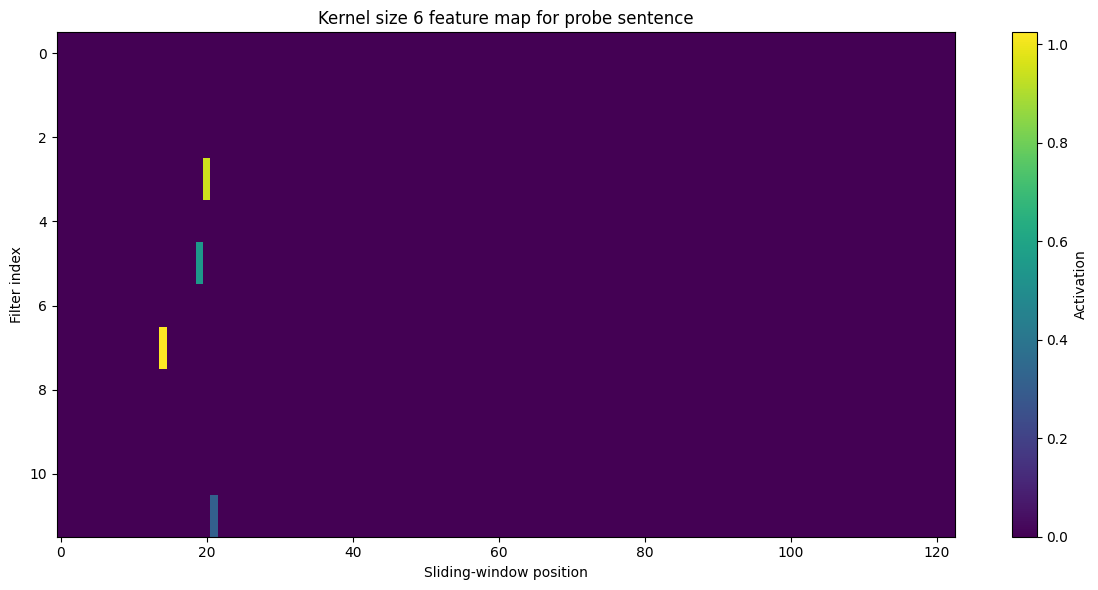

kernel=10 | feature_map shape=(64, 119) | pooled shape=(64,)


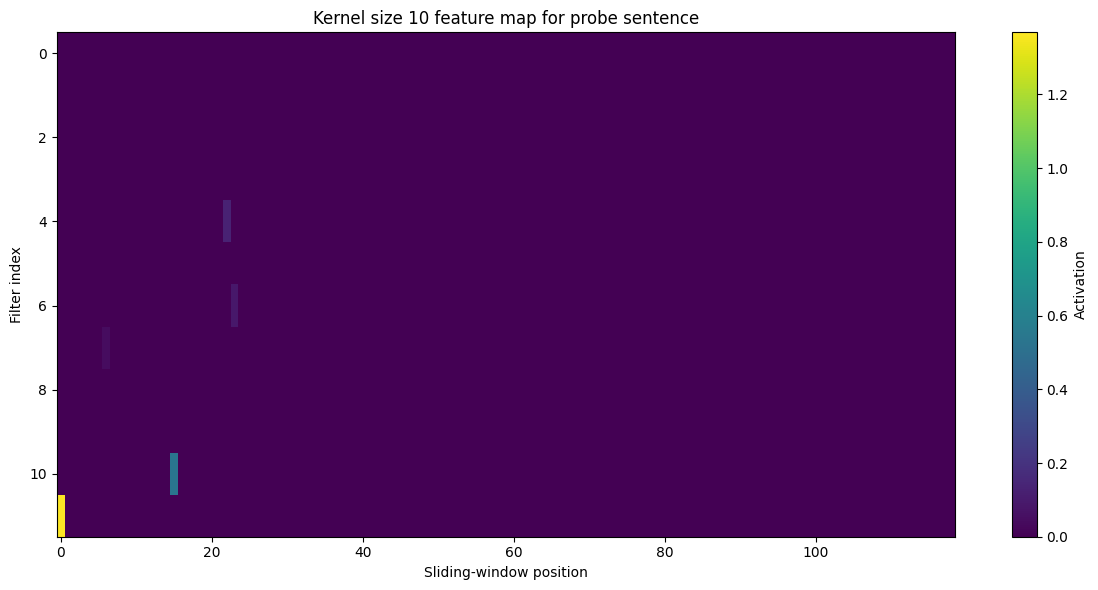

kernel=16 | feature_map shape=(64, 113) | pooled shape=(64,)


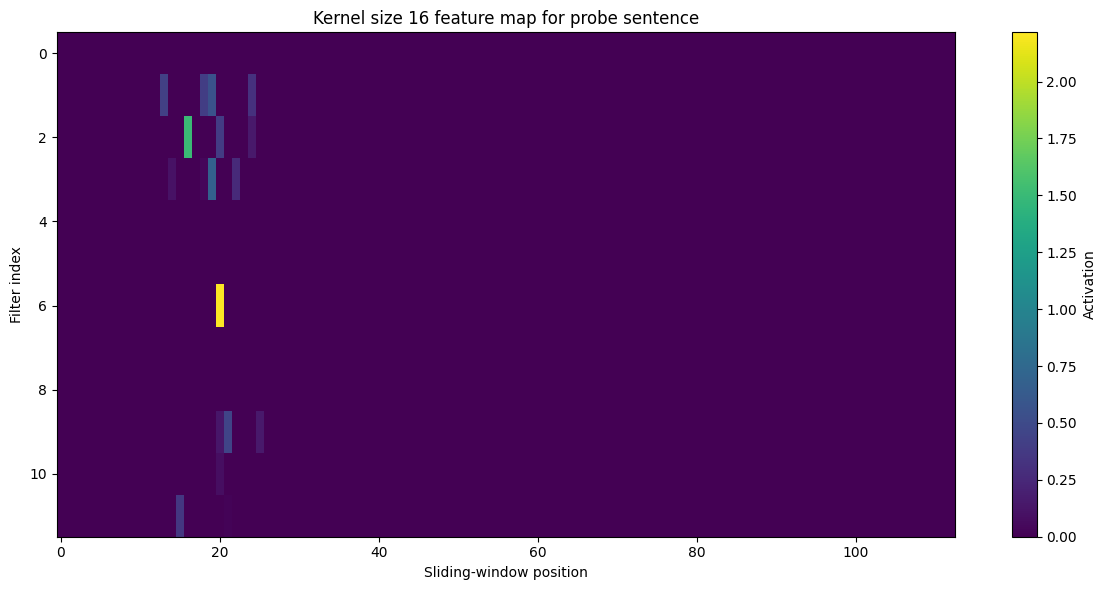

In [12]:
probe_text = "Parts are disappointing but the overall movie is charming."
probe_ids, probe_masks = bpe_batch_encode(
    sentences=[probe_text],
    bpe_merges=bpe_merges,
    bpe_vocab=bpe_vocab,
    max_seq=max_seq,
    pad_token=pad_token,
)
probe_ids = probe_ids.to(device)
probe_masks = probe_masks.to(device)

best_model.eval()
with torch.no_grad():
    feature_maps, sentence_features = best_model.extract_feature_maps(probe_ids, probe_masks)
    prob = torch.sigmoid(best_model(probe_ids, probe_masks)).item()

print(f"probe text: {probe_text}")
print(f"word tokens: {word_tokenizer(probe_text)}")
print(f"predicted positive probability: {prob:.3f}")

for kernel_size, payload in feature_maps.items():
    activations = payload["activations"][0]
    pooled = payload["pooled"][0]
    print(f"kernel={kernel_size} | feature_map shape={tuple(activations.shape)} | pooled shape={tuple(pooled.shape)}")
    plot_feature_map_heatmap(
        activations,
        kernel_size=kernel_size,
        title=f"Kernel size {kernel_size} feature map for probe sentence",
        max_filters=12,
    )

## Which Filters Actually Drive The Prediction?
The final classifier does not read one activation in isolation. It reads the **pooled** activation from every filter, multiplies each pooled value by its final linear-layer weight, adds them together with a bias term, and produces one logit.

So the useful quantity to inspect is:

`filter contribution = pooled_activation * classifier_weight`

- a large positive contribution pushes the sentence toward the positive class
- a large negative contribution pushes the sentence toward the negative class
- a moderate activation can still support the negative class if its classifier weight is negative

This means a high pooled activation is not automatically the most important signal. A filter only has a strong effect on the final decision when its pooled activation is combined with a large-magnitude final linear-layer weight.

In [13]:
rows = []
linear_weights = best_model.linear.weight[0].detach().cpu()
bias = float(best_model.linear.bias[0].detach().cpu())
offset = 0

for kernel_size in best_model.kernel_sizes:
    payload = feature_maps[kernel_size]
    approx_spans = get_approx_word_window_spans(probe_text, bpe_merges, kernel_size)
    activations = payload["activations"][0].detach().cpu()
    conv_mask = payload["mask"][0].detach().cpu()
    pooled = payload["pooled"][0].detach().cpu()
    masked_activations = activations.masked_fill(~conv_mask.unsqueeze(0), float("-inf"))
    max_positions = masked_activations.argmax(dim=1)

    for filter_idx in range(activations.shape[0]):
        pooled_activation = float(pooled[filter_idx])
        classifier_weight = float(linear_weights[offset + filter_idx])
        contribution = pooled_activation * classifier_weight
        max_position = int(max_positions[filter_idx])
        rows.append(
            {
                "kernel": kernel_size,
                "filter": filter_idx,
                "max_position": max_position,
                "approx_span": approx_spans[max_position] if max_position < len(approx_spans) else "<span unavailable>",
                "pooled_activation": pooled_activation,
                "classifier_weight": classifier_weight,
                "contribution": contribution,
            }
        )
    offset += activations.shape[0]

rows_sorted_positive = sorted(rows, key=lambda row: row["contribution"], reverse=True)
rows_sorted_negative = sorted(rows, key=lambda row: row["contribution"])
total_feature_contrib = sum(row["contribution"] for row in rows)
logit = total_feature_contrib + bias
prob_from_parts = float(torch.sigmoid(torch.tensor(logit)))

print(f"bias contribution: {bias:.4f}")
print(f"sum of filter contributions: {total_feature_contrib:.4f}")
print(f"final logit from decomposition: {logit:.4f}")
print(f"probability from decomposition: {prob_from_parts:.4f}")
print("approx_span is a readable word-level approximation of the BPE window where that filter reached its max.")
print()
print("Top 8 positive filter contributions:")
for row in rows_sorted_positive[:8]:
    print(
        f"kernel={row['kernel']} filter={row['filter']:02d} pos={row['max_position']:02d} | "
        f"pooled={row['pooled_activation']:.3f} weight={row['classifier_weight']:.3f} "
        f"contribution={row['contribution']:.3f} | approx_span='{row['approx_span']}'"
    )

print()
print("Top 8 negative filter contributions:")
for row in rows_sorted_negative[:8]:
    print(
        f"kernel={row['kernel']} filter={row['filter']:02d} pos={row['max_position']:02d} | "
        f"pooled={row['pooled_activation']:.3f} weight={row['classifier_weight']:.3f} "
        f"contribution={row['contribution']:.3f} | approx_span='{row['approx_span']}'"
    )

bias contribution: 0.0150
sum of filter contributions: -1.0881
final logit from decomposition: -1.0731
probability from decomposition: 0.2548
approx_span is a readable word-level approximation of the BPE window where that filter reached its max.

Top 8 positive filter contributions:
kernel=16 filter=24 pos=08 | pooled=1.089 weight=0.159 contribution=0.174 | approx_span='disappointing but the overall movie is charming'
kernel=6 filter=03 pos=20 | pooled=0.950 weight=0.111 contribution=0.105 | approx_span='is charming.'
kernel=10 filter=47 pos=13 | pooled=0.553 weight=0.130 contribution=0.072 | approx_span='the overall movie is charming'
kernel=6 filter=05 pos=19 | pooled=0.548 weight=0.126 contribution=0.069 | approx_span='movie is charming'
kernel=10 filter=62 pos=09 | pooled=0.743 weight=0.087 contribution=0.065 | approx_span='disappointing but the overall movie'
kernel=16 filter=52 pos=00 | pooled=0.489 weight=0.097 contribution=0.047 | approx_span='Parts are disappointing but the ov

## CNN vs. RNN
- CNNs are fast and parallelizable because all windows can be processed at once.
- CNNs are especially good when the label depends on local phrase evidence such as negation or strong sentiment expressions.
- RNNs are more naturally aligned with information that accumulates gradually across a long sequence.
- Gradient clipping is often more important for RNNs because recurrence can make optimization less stable; we keep it here as a general safeguard, not because it is a defining part of CNN training.
- In practice, `TextCNN` is a very strong model when local phrase detection is the main learning problem.
-  a CNN with global max pooling is order-invariant at the sentence level (it knows "this pattern exists somewhere" but not "where relative to other patterns"). This is exactly why the competing-cues category is hard for it.

## Summary
`TextCNN` replaces hand-written n-gram counting with learned sliding-window detectors over embeddings. Multiple filters learn different local patterns, parameter sharing makes those detectors reusable across positions, and global max pooling turns strong local evidence into a sentence-level signal for classification.